# Tema 16 — Despliegue de un modelo con API REST (Flask + TensorFlow Serving)

En este notebook exponemos un modelo de visión por computadora como un **servicio web**. Construimos una **API REST** con **Flask** (en el puerto `5001`) que recibe una imagen, la preprocesa y la reenvía a un servidor de inferencia (**TensorFlow Serving**, en el puerto `8501`) para obtener la predicción.

> 💡 Para obtener predicciones reales necesitas **TensorFlow Serving** con un modelo llamado `modelo`. Consulta el `README.md` de la `semana-08` (sección 4.2) para levantarlo con Docker —o sin Docker— en macOS, Windows o Linux. Sin ese servicio, `/predict` responde con un `502` controlado.

**Servicio de inferencia mediante API REST**

### ¿Qué hace este código?

Define una **API REST** con Flask que sirve las predicciones de un modelo:

1. Crea la app de **Flask** (puerto `5001`) y apunta a un servidor de inferencia de **TensorFlow Serving** (`TF_SERVING_URL`, puerto `8501`).
2. `preprocess_image` **redimensiona** la imagen a 224×224, la **normaliza** (0–1) y le agrega la dimensión de *batch* que espera el modelo.
3. El endpoint **`/predict`** recibe la imagen por `POST`, la decodifica con **OpenCV**, la preprocesa y la reenvía al servicio de inferencia.
4. Devuelve las **predicciones** en JSON y maneja los errores (imagen faltante, fallo de conexión, error interno) con **códigos HTTP** adecuados.

> ⚠️ La app corre con `app.run(...)`, que **bloquea** la celda mientras el servidor está activo (deténla con el botón ■ para continuar). Se usa el puerto **`5001`** porque en macOS el `5000` lo ocupa *AirPlay Receiver*.

**Cómo probarlo:** con esta celda en ejecución **y** TensorFlow Serving activo en `localhost:8501` (ver `README.md`, sección 4.2), envía una imagen desde **otra terminal** con:

`curl -X POST -F "file=@/ruta/a/tu/imagen.jpg" http://127.0.0.1:5001/predict`

Sin TensorFlow Serving, `/predict` responde con un `502` controlado.

In [11]:
from flask import Flask, request, jsonify
import numpy as np
import cv2
import requests
app = Flask(__name__)
# URL del servicio de inferencia
TF_SERVING_URL = "http://localhost:8501/v1/models/modelo:predict"

def preprocess_image(image):
    image = cv2.resize(image, (224, 224))
    image = image.astype("float32") / 255.0
    image = np.expand_dims(image, axis=0)
    return image.tolist()
@app.route("/predict", methods=["POST"])
def predict():
    try:
        if "file" not in request.files:
            return jsonify({"error": "No se envió ninguna imagen"}), 400
        file = request.files["file"]
        image_bytes = np.frombuffer(file.read(), np.uint8)
        image = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
        if image is None:
            return jsonify({"error": "La imagen no pudo procesarse"}), 400
        processed = preprocess_image(image)
        response = requests.post(
            TF_SERVING_URL,
            json={"instances": processed},
            timeout=10
        )
        response.raise_for_status()
        predictions = response.json()
        return jsonify(predictions), 200

    except requests.exceptions.RequestException as e:
        return jsonify({"error": "No fue posible conectar con el servicio de inferencia",
                        "detalle": str(e)}), 502
    except Exception as e:
        return jsonify({"error": "Error interno del servidor",
                        "detalle": str(e)}), 500
if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5001)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://192.0.0.2:5001
Press CTRL+C to quit


**Prueba de inferencia: top-5 de ImageNet con nombres**

### ¿Qué hace este código?

Prueba el modelo con una imagen y muestra las **5 clases más probables** con su nombre y porcentaje:

1. Carga `data/imagen_prueba.jpg` y la preprocesa **igual que la API**: la redimensiona a 224×224 y la normaliza a valores en 0–1.
2. La envía **directamente a TensorFlow Serving** (`localhost:8501`) y recibe los **1001 puntajes (logits)** de MobileNet.
3. Muestra algunos **valores crudos** (logits) tal como los devuelve el modelo, **antes** de normalizarlos, para que se vea la diferencia con las probabilidades.
4. Aplica **softmax** para convertir esos puntajes en **probabilidades** (0–100 % que suman 100 %).
5. Descarga las **etiquetas de ImageNet** y muestra el **top-5** (nombre + porcentaje), junto con la imagen y su predicción principal.

> 💡 Esta celda habla **directo** con TensorFlow Serving (puerto 8501) porque la celda anterior (`app.run`) **bloquea** el kernel del notebook. Para probar la **API de Flask completa** (puerto 5001), usa el comando `curl` desde otra terminal (ver `README.md`). Requiere que **TensorFlow Serving** esté activo.

El modelo devuelve 1001 numeros, uno por clase (1000 de ImageNet + 'background').
Primeros 10 valores crudos (logits):
[ 0.195  1.161 -0.075  0.925 -0.079 -0.989 -0.456 -2.046 -0.189 -0.169]
Mas alto: 9.962 (indice 653)   |   Mas bajo: -2.929
Nota: son puntajes sin normalizar (pueden ser negativos o > 1); NO suman 1.
-----------------------------------------------------------------
Top-5 predicciones (ya con softmax):
  military uniform        87.6%  (indice 653)
  suit                     1.2%  (indice 835)
  bearskin                 0.8%  (indice 440)
  ballplayer               0.7%  (indice 982)
  mortarboard              0.6%  (indice 668)


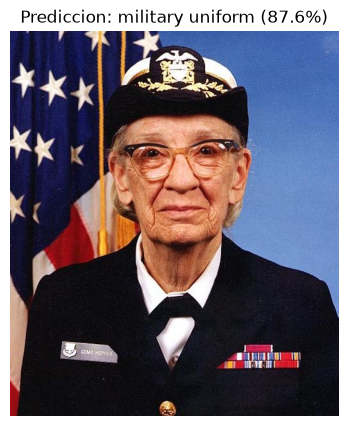

In [ ]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

NO_PROXY = {"http": None, "https": None}
IMG_PATH = "data/imagen_prueba.jpg"
TFS_URL = "http://localhost:8501/v1/models/modelo:predict"

# 1) Cargar y preprocesar la imagen igual que la API (224x224, valores en [0, 1])
img_bgr = cv2.imread(IMG_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
entrada = cv2.resize(img_rgb, (224, 224)).astype("float32") / 255.0

# 2) Enviar a TensorFlow Serving y obtener los 1001 puntajes (logits)
resp = requests.post(TFS_URL, json={"instances": [entrada.tolist()]},
                     proxies=NO_PROXY, timeout=60)
resp.raise_for_status()
logits = np.array(resp.json()["predictions"][0])

# 2.5) Ver los numeros CRUDOS que devuelve el modelo (ANTES de softmax)
print(f"El modelo devuelve {logits.size} numeros, uno por clase (1000 de ImageNet + 'background').")
print("Primeros 10 valores crudos (logits):")
print(np.round(logits[:10], 3))
print(f"Mas alto: {logits.max():.3f} (indice {int(logits.argmax())})   |   Mas bajo: {logits.min():.3f}")
print("Nota: son puntajes sin normalizar (pueden ser negativos o > 1); NO suman 1.")
print("-" * 65)

# 3) Softmax: convertir los puntajes en probabilidades (0-1 que suman 1)
probs = np.exp(logits - logits.max())
probs = probs / probs.sum()

# 4) Etiquetas de ImageNet (1001; el indice 0 es 'background')
etiquetas = requests.get(
    "https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt",
    proxies=NO_PROXY, timeout=30,
).text.splitlines()

# 5) Top-5 clases con mayor probabilidad
top5 = probs.argsort()[-5:][::-1]
print("Top-5 predicciones (ya con softmax):")
for i in top5:
    print(f"  {etiquetas[i]:<22} {probs[i] * 100:5.1f}%  (indice {i})")

# 6) Mostrar la imagen con su prediccion principal
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Prediccion: {etiquetas[top5[0]]} ({probs[top5[0]] * 100:.1f}%)")
plt.show()

**Comparación visual: logits vs. probabilidades (top-5)**

Dos gráficos de barras del **top-5**: a la izquierda los **logits** crudos que devuelve el modelo y a la derecha las **probabilidades** tras aplicar **softmax**. Sirve para ver cómo softmax convierte puntajes arbitrarios (con negativos, sin escala fija) en porcentajes que **suman 100 %**.

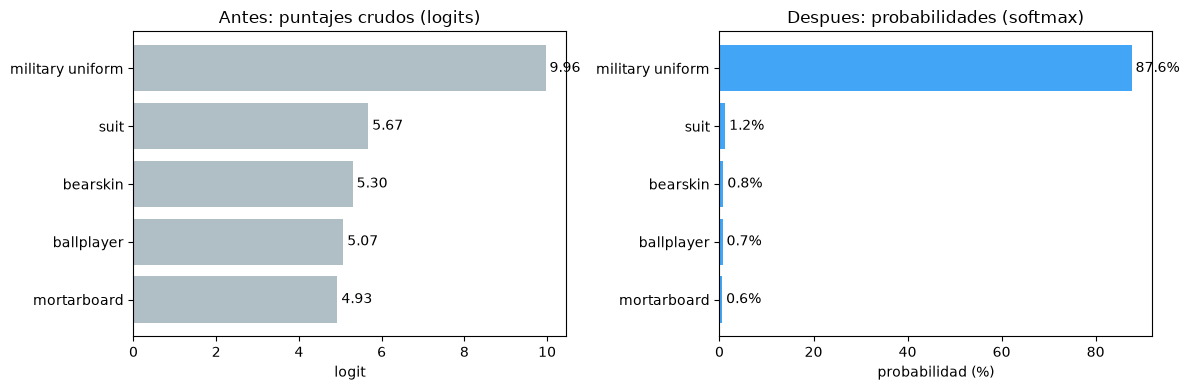

In [ ]:
# Grafico comparativo del top-5: logits crudos vs. probabilidades (softmax)
nombres = [etiquetas[i] for i in top5]
logits_top = [float(logits[i]) for i in top5]
probs_top = [float(probs[i]) * 100 for i in top5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: puntajes crudos (lo que devuelve el modelo, ANTES de softmax)
ax1.barh(nombres, logits_top, color="#B0BEC5")
ax1.invert_yaxis()
ax1.set_title("Antes: puntajes crudos (logits)")
ax1.set_xlabel("logit")
for y, v in enumerate(logits_top):
    ax1.text(v, y, f" {v:.2f}", va="center")

# Derecha: probabilidades DESPUES de softmax
ax2.barh(nombres, probs_top, color="#42A5F5")
ax2.invert_yaxis()
ax2.set_title("Despues: probabilidades (softmax)")
ax2.set_xlabel("probabilidad (%)")
for y, v in enumerate(probs_top):
    ax2.text(v, y, f" {v:.1f}%", va="center")

plt.tight_layout()
plt.show()